# Computing solar heating from observations

In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from matplotlib.gridspec import GridSpec
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools


import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_86690/1588018898.py:46: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


cmocean      : 3.0.3
regionmask   : 0.12.1
intake_esm   : 2023.6.14
shapely      : 2.0.1
intake       : 0.7.0
salem        : 0.3.10
pandas       : 2.0.2
seaborn      : 0.12.2
dask_jobqueue: 0.8.2
numpy        : 1.23.5
matplotlib   : 3.7.1
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
xarray       : 2023.6.0
pop_tools    : 2023.3.0
cartopy      : 0.21.1
cf_xarray    : 0.8.2
distributed  : 2023.6.0
pint_xarray  : 0.3
xeofs        : 1.0.3
geopandas    : 0.13.2



In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

In [31]:
ds_heating = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_obs.nc')
ds_heating

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
    month    (time) int64 ...
Data variables:
    I        (time) float32 ...
    II       (time) float32 ...
    III      (time) float32 ...
    IV       (time) float32 ...
    V        (time) float32 ...
    VI       (time) float32 ...
    VII      (time) float32 ...
    VIII     (time) float32 ...

In [32]:
ds_q_prime_obs = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_obs.nc')
ds_q_prime_obs

<xarray.Dataset>
Dimensions:      (time: 492)
Coordinates:
  * time         (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
    month        (time) int64 ...
Data variables:
    q_prime_ice  (time) float32 ...
    q_prime_ocn  (time) float32 ...

### Computing from 1982-2002 mean 

In [34]:
################
sel_mjja_obs = (ds_heating['time.month'] >= 5) & (ds_heating['time.month'] <= 8)

ds_mjja_obs = ds_heating.sel(time=sel_mjja_obs)

ds_qprime_mjja_obs = ds_q_prime_obs.sel(time=sel_mjja_obs)


######################
def get_seconds_per_month(time):
    return xr.DataArray(
        [pd.Period(f"{t.dt.year.values}-{t.dt.month.values}").days_in_month * 24 * 3600
         for t in time],
        coords={"time": time},
        dims="time"
    )

seconds_per_month_obs = get_seconds_per_month(ds_mjja_obs['time'])

#######################

ds_accum_month_obs = ds_mjja_obs * seconds_per_month_obs

ds_qprime_accum_month_obs = ds_qprime_mjja_obs * seconds_per_month_obs


#######################

ds_accum_year_obs = ds_accum_month_obs.groupby("time.year").sum()

ds_qprime_accum_year_obs = ds_qprime_accum_month_obs.groupby("time.year").sum()


######################




In [37]:
ds_qprime_accum_year_obs

<xarray.Dataset>
Dimensions:      (year: 41)
Coordinates:
  * year         (year) int64 1982 1983 1984 1985 1986 ... 2019 2020 2021 2022
Data variables:
    q_prime_ice  (year) float64 1.66e+07 3.53e+07 ... 1.778e+06 1.735e+08
    q_prime_ocn  (year) float64 7.478e+06 2.09e+07 ... 1.767e+07 1.412e+08

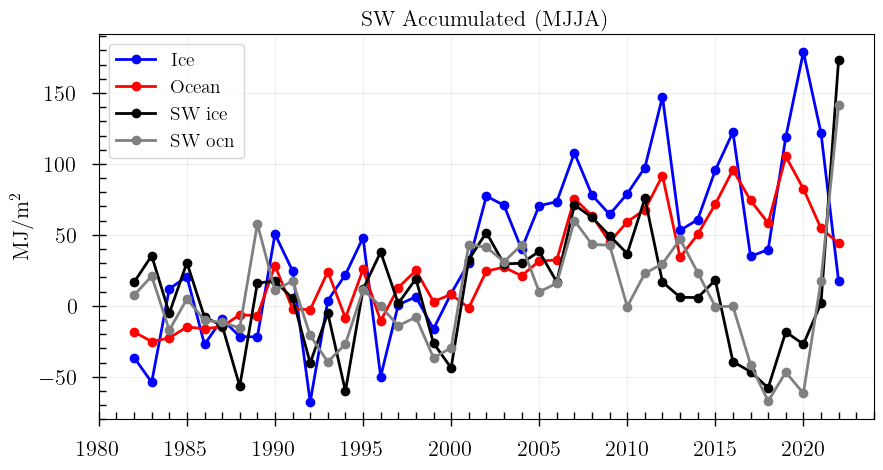

In [44]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_accum_year_obs['year'], 1e-6 * ds_accum_year_obs['II'], '-o', c='b', lw=2, label='Ice')
ax.plot(ds_accum_year_obs['year'], 1e-6 * ds_accum_year_obs['I'], '-o', c='r', lw=2, label='Ocean')
ax.plot(ds_accum_year_obs['year'], 1e-6 * ds_qprime_accum_year_obs['q_prime_ice'], '-o', c='k', lw=2, label='SW ice')
ax.plot(ds_accum_year_obs['year'], 1e-6 * ds_qprime_accum_year_obs['q_prime_ocn'], '-o', c='grey', lw=2, label='SW ocn')

ax.tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.set_ylabel(r'MJ/m$^2$', fontsize=16)
ax.set_title(r'SW Accumulated (MJJA)', fontsize=16)
ax.legend(fontsize=14)
plt.show()


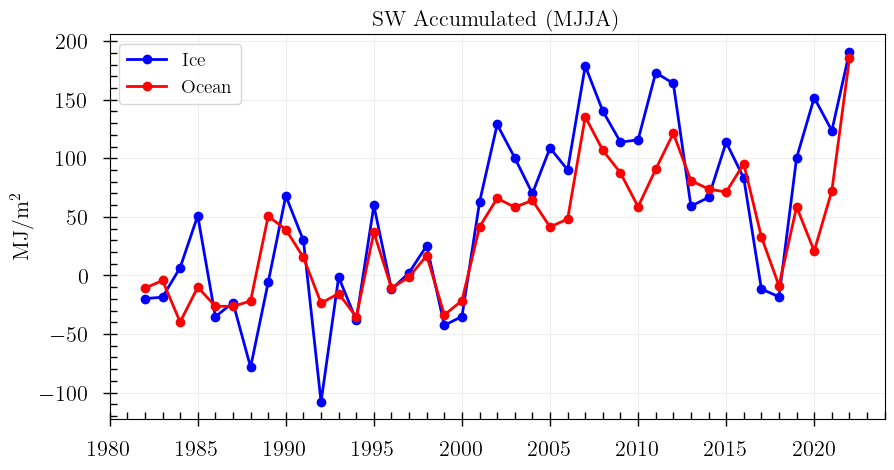

In [38]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(ds_accum_year_obs['year'], 1e-6 * (ds_accum_year_obs['II']+
                                           ds_qprime_accum_year_obs['q_prime_ice'])
                                            , '-o', c='b', lw=2, label='Ice')
ax.plot(ds_accum_year_obs['year'], 1e-6 * (ds_accum_year_obs['I']+
                                           ds_qprime_accum_year_obs['q_prime_ocn'])
                                            , '-o', c='r', lw=2, label='Ocean')

ax.tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.set_ylabel(r'MJ/m$^2$', fontsize=16)
ax.set_title(r'SW Accumulated (MJJA)', fontsize=16)
ax.legend(fontsize=14)
plt.show()


### Computing sea ice area

In [39]:
ds_nsidc

<xarray.Dataset>
Dimensions:          (time: 492, y: 448, x: 304)
Coordinates:
    xgrid            (x) float32 ...
    ygrid            (y) float32 ...
    latitude         (y, x) float32 31.1 31.2 31.3 31.39 ... 34.68 34.58 34.47
    longitude        (y, x) float32 ...
  * time             (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Dimensions without coordinates: y, x
Data variables:
    cdr_seaice_conc  (time, y, x) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/39)
    Conventions:               CF-1.6, ACDD-1.3
    title:                     NOAA/NSIDC Climate Data Record of Passive Micr...
    references:                Comiso, J. C., and F. Nishio. 2008. Trends in ...
    comment:                   none
    program:                   NOAA Climate Data Record Program
    cdr_variable:              cdr_seaice_conc
    ...                        ...
    acknowledgment:            This project was supported in part by a grant ...
    platform:                  NIMBUS-7
    sensor:                    SMMR > Scanning Multichannel Microwave Radiometer
    date_created:              2021-06-21T17:19:22Z
    time_coverage_start:       1982-01-01T00:00:00Z
    time_coverage_end:         1982-12-31T23:59:59Z

In [40]:
# assume your dataset is called ds
sic = ds_nsidc['cdr_seaice_conc']

# 1️⃣ Compute grid spacing (in meters)
dx = np.abs(ds_nsidc.xgrid.diff('x').mean().item())
dy = np.abs(ds_nsidc.ygrid.diff('y').mean().item())

print(f"Grid spacing: dx={dx:.1f} m, dy={dy:.1f} m")

# 2️⃣ Compute grid cell area
cell_area = dx * dy  # in m²

# 3️⃣ Convert SIC to fraction and mask invalid values
sic = sic.where((sic >= 0) & (sic <= 1))

# 4️⃣ Compute total ice-covered area (sum over spatial dims)
seaice_area = (sic * cell_area).sum(dim=['y', 'x'])

# 5️⃣ Convert to million km²
seaice_area_mkm2 = (seaice_area / 1e6) / 1e6
seaice_area_mkm2.name = 'seaice_area_million_km2'

seaice_area_mkm2


Grid spacing: dx=25000.0 m, dy=25000.0 m


<xarray.DataArray 'seaice_area_million_km2' (time: 492)>
array([14.357784 , 15.229325 , 15.333651 , 14.696651 , 13.028858 ,
       11.238289 ,  9.086908 ,  7.150245 ,  6.5719113,  8.528151 ,
       10.716951 , 12.802279 , 14.183435 , 15.326203 , 15.390678 ,
       14.31971  , 12.676829 , 11.243634 ,  9.282406 ,  7.1205754,
        6.6951466,  8.461545 , 10.644109 , 12.525851 , 13.794404 ,
       14.62881  , 14.931125 , 14.280511 , 12.724091 , 11.043801 ,
        9.954865 ,  6.786808 ,  6.2575717,  7.822828 , 10.103151 ,
       12.258008 , 13.999429 , 14.784889 , 15.164168 , 14.631366 ,
       13.151634 , 10.951542 ,  8.588674 ,  6.6229486,  6.2051263,
        7.835447 , 10.163872 , 12.225819 , 14.056534 , 15.056565 ,
       15.268181 , 14.174503 , 12.57776  , 10.956604 ,  8.958849 ,
        7.022235 ,  6.7323804,  8.609281 , 10.64711  , 12.635411 ,
       14.243187 , 15.411266 , 15.13396  , 14.475284 , 12.881741 ,
       11.279954 ,  9.006187 ,  6.6150823,  6.64691  ,  8.392435 ,
       10.470487 , 11.778221 , 14.444319 , 15.034075 , 15.353824 ,
       14.286598 , 12.500557 , 10.617688 ,  8.525428 ,  6.8211584,
        6.6551237,  8.470317 , 10.576711 , 12.859892 , 14.24518  ,
       14.767537 , 14.577373 , 13.383322 , 12.124146 , 10.882982 ,
        8.692572 ,  6.7153344,  6.1783366,  8.134963 , 10.34716  ,
       12.629307 , 14.080481 , 14.967041 , 15.137852 , 13.62685  ,
...
       11.472181 , 12.787379 , 13.631136 , 13.493158 , 12.956454 ,
       11.400098 ,  9.428624 ,  6.8140483,  4.499565 ,  3.9649858,
        6.2143617,  9.039297 , 11.167655 , 12.622088 , 13.395861 ,
       13.583724 , 12.647325 , 10.794578 ,  8.936532 ,  6.5875425,
        4.2216935,  3.7469013,  5.3604803,  7.8577933, 10.503803 ,
       12.303619 , 13.226005 , 13.390227 , 12.779701 , 11.505532 ,
        9.131834 ,  6.627928 ,  4.532724 ,  4.1587024,  6.0436296,
        8.633661 , 10.847418 , 12.284145 , 13.130875 , 13.471332 ,
       12.76528  , 11.190184 ,  9.422541 ,  6.8292394,  4.5902085,
        4.080977 ,  5.451518 ,  9.022278 , 11.007921 , 12.768998 ,
       13.593025 , 13.693331 , 12.422421 , 11.021101 ,  9.017189 ,
        6.1533403,  4.07236  ,  3.7347882,  5.068606 ,  8.495116 ,
       11.05453  , 12.835124 , 13.819161 , 13.811882 , 12.636393 ,
       11.15012  ,  9.106302 ,  6.0695515,  3.9834945,  3.394357 ,
        4.682589 ,  8.144901 , 10.812484 , 12.603094 , 13.551784 ,
       13.782662 , 12.783917 , 11.461223 ,  9.196239 ,  6.522716 ,
        4.6425867,  4.186038 ,  6.098336 ,  9.022788 , 11.255107 ,
       13.012026 , 13.742589 , 13.650334 , 13.041491 , 11.697157 ,
        9.289047 ,  6.9810104,  4.8651414,  4.1826167,  5.924461 ,
        8.944555 , 10.983413 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1982-01-31 1982-02-28 ... 2022-12-31
Attributes:
    long_name:            NOAA/NSIDC Climate Data Record of Passive Microwave...
    standard_name:        sea_ice_area_fraction
    units:                1
    flag_values:          [251 252 253 254 255]
    flag_meanings:        pole_hole lakes coastal land_mask missing_data
    datum:                +ellps=urn:ogc:def:crs:EPSG::4326
    grid_mapping:         projection
    reference:            https://nsidc.org/data/g02202/versions/4/
    ancillary_variables:  stdev_of_cdr_seaice_conc qa_of_cdr_seaice_conc
    valid_range:          [  0 100]
    cell_methods:         tdim: mean

In [41]:
# --- 4. Remove negative or unrealistic values ---
# Example: below 0 or above 20 million km² (Arctic typical range ~0–15)
seaice_area_mkm2 = seaice_area_mkm2.where(
    (seaice_area_mkm2 >= 2) & (seaice_area_mkm2 <= 20)
)

# --- 5. (Optional) Remove statistical outliers ---
# Compute z-scores to remove isolated spikes
z = (seaice_area_mkm2 - seaice_area_mkm2.mean()) / seaice_area_mkm2.std()
seaice_area_mkm2 = seaice_area_mkm2.where(np.abs(z) < 3)



In [42]:
# --- Select only May–August (MJJA) ---
mjja_sia = seaice_area_mkm2.sel(time=seaice_area_mkm2['time'].dt.month.isin([5, 6, 7, 8]))

# --- Compute MJJA mean per year ---
mjja_mean_sia = mjja_sia.resample(time="1Y").mean()


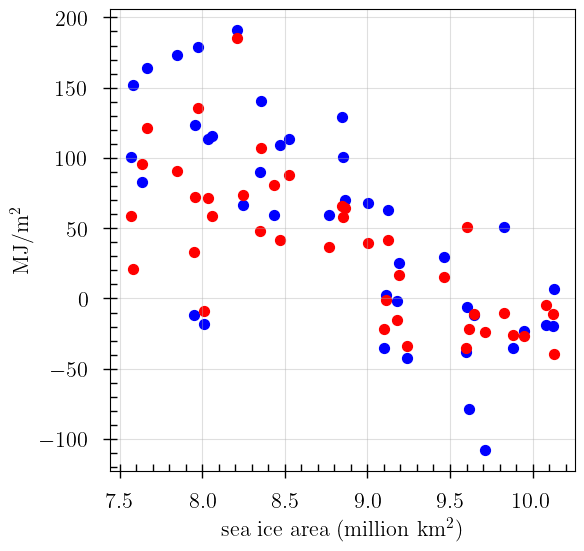

In [43]:
fig, ax = plt.subplots(figsize=(6,6))


# Scatter all ensemble points (optional)
ax.scatter(mjja_mean_sia, 1e-6 * (ds_accum_year_obs['II']+
                                           ds_qprime_accum_year_obs['q_prime_ice']), c='b',s=50)
ax.scatter(mjja_mean_sia, 1e-6 * (ds_accum_year_obs['I']+
                                           ds_qprime_accum_year_obs['q_prime_ocn']), c='r', s=50)


# Axis formatting
ax.tick_params(which='both', labelcolor='k', labelsize=16, direction='inout', width=1, length=10, pad=10)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.4)
ax.set_xlabel(r'sea ice area (million km$^2$)', fontsize=16)
ax.set_ylabel(r'MJ/m$^2$', fontsize=16)

plt.show()


In [31]:
# Save to NetCDF
# ds_solar.to_netcdf("~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/obs_solar_heating.nc")
# 